In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

In [ ]:
!pip install xlrd openpyxl

In [ ]:
# df = pd.read_excel('/content/sample_data/Mall_Customers.xls', engine='xlrd')
df = pd.read_csv('/content/sample_data/Mall_Customers.xls')

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [ ]:

df = df.drop(['CustomerID'], axis=1)


df['Gender'] = df['Gender'].map({'Male': 0, 'Female': 1})

scaler = StandardScaler()
X = scaler.fit_transform(df)

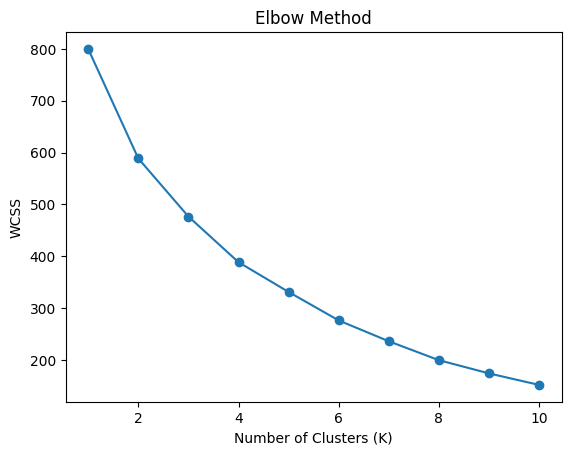

In [ ]:
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')
plt.show()

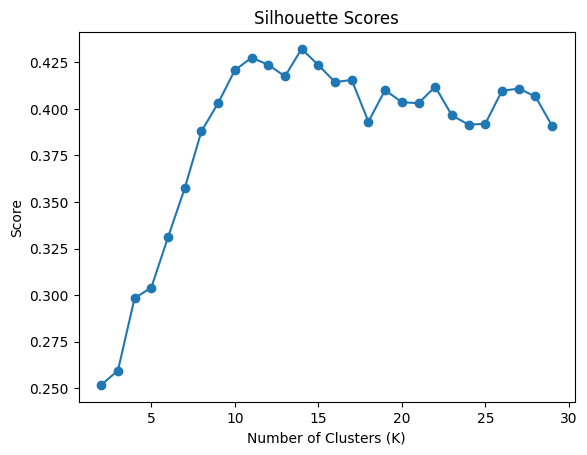

Optimal K (Silhouette): 14


In [ ]:
sil_scores = []

for k in range(2, 30):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X)
    score = silhouette_score(X, labels)
    sil_scores.append(score)

plt.plot(range(2, 30), sil_scores, marker='o')
plt.title('Silhouette Scores')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Score')
plt.show()

best_k = range(2, 30)[np.argmax(sil_scores)]
print("Optimal K (Silhouette):", best_k)

In [ ]:
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X)

df['Cluster'] = clusters
df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,0,19,15,39,1
1,0,21,15,81,1
2,1,20,16,6,2
3,1,23,16,77,8
4,1,31,17,40,2


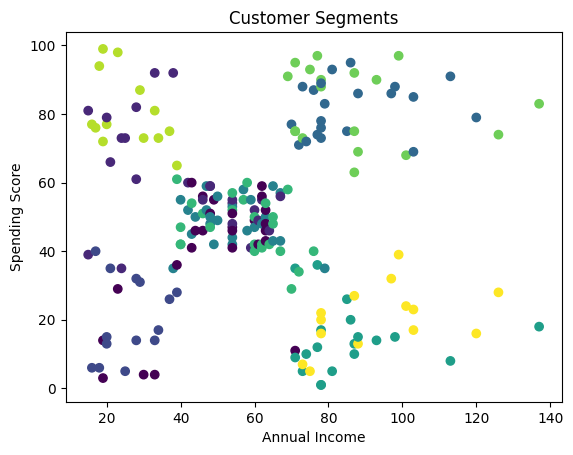

In [ ]:
plt.scatter(df['Annual Income (k$)'], df['Spending Score (1-100)'], c=clusters)

plt.xlabel('Annual Income')
plt.ylabel('Spending Score')
plt.title('Customer Segments')


plt.show()

In [ ]:
centers = scaler.inverse_transform(kmeans.cluster_centers_)
print(pd.DataFrame(centers, columns=df.columns[:-1]))

     Gender        Age  Annual Income (k$)  Spending Score (1-100)
0  0.000000  58.846154           48.692308               39.846154
1  0.000000  25.250000           41.250000               60.916667
2  0.928571  41.214286           26.071429               20.142857
3  1.000000  32.190476           86.047619               81.666667
4  1.000000  54.153846           54.230769               48.961538
5  0.000000  38.473684           85.894737               14.210526
6  1.000000  27.960000           57.360000               47.120000
7  0.000000  33.277778           87.111111               82.666667
8  1.000000  25.461538           25.692308               80.538462
9  1.000000  43.785714           93.285714               20.642857


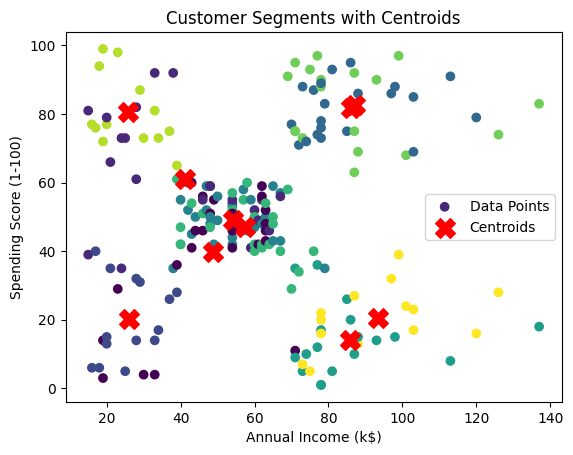

In [ ]:
plt.scatter(df['Annual Income (k$)'], df['Spending Score (1-100)'], c=clusters, label='Data Points')
plt.scatter(centers[:,2],centers[:,3], marker='X', s=200, label="Centroids", color='red')
plt.title('Customer Segments with Centroids')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.show()